<a href="https://colab.research.google.com/github/Kaweri05/AI-Handwritten-Digit-Recognition/blob/main/AI_Handwritten_Digit_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [ ]:
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training Images:", X_train.shape)
print("Testing Images:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images: (60000, 28, 28)
Testing Images: (10000, 28, 28)


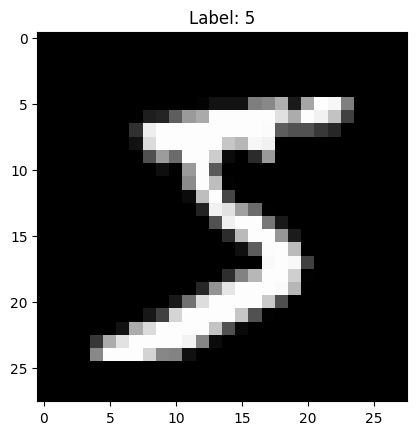

In [ ]:
plt.imshow(X_train[0], cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.show()

In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [ ]:
X_train = X_train.reshape(
    X_train.shape[0],
    28,
    28,
    1
)

X_test = X_test.reshape(
    X_test.shape[0],
    28,
    28,
    1
)

print(X_train.shape)

(60000, 28, 28, 1)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(28,28,1)
    )
)

model.add(
    MaxPooling2D(
        (2,2)
    )
)

model.add(
    Flatten()
)

model.add(
    Dense(
        128,
        activation='relu'
    )
)

model.add(
    Dense(
        10,
        activation='softmax'
    )
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_data=(X_test, y_test)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.9581 - loss: 0.1427 - val_accuracy: 0.9808 - val_loss: 0.0564
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 23ms/step - accuracy: 0.9846 - loss: 0.0490 - val_accuracy: 0.9829 - val_loss: 0.0519
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 52s 28ms/step - accuracy: 0.9901 - loss: 0.0310 - val_accuracy: 0.9843 - val_loss: 0.0491
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 46s 24ms/step - accuracy: 0.9940 - loss: 0.0193 - val_accuracy: 0.9852 - val_loss: 0.0482
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 84s 25ms/step - accuracy: 0.9959 - loss: 0.0128 - val_accuracy: 0.9852 - val_loss: 0.0481


In [ ]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9852 - loss: 0.0481
Accuracy: 0.9851999878883362


In [ ]:
model.save("digit_model.keras")

In [ ]:
from google.colab import files

files.download("digit_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
prediction = model.predict(
    X_test[:1]
)

print(
    "Predicted:",
    np.argmax(prediction)
)

print(
    "Actual:",
    y_test[0]
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
Predicted: 7
Actual: 7


### Visualize Training History

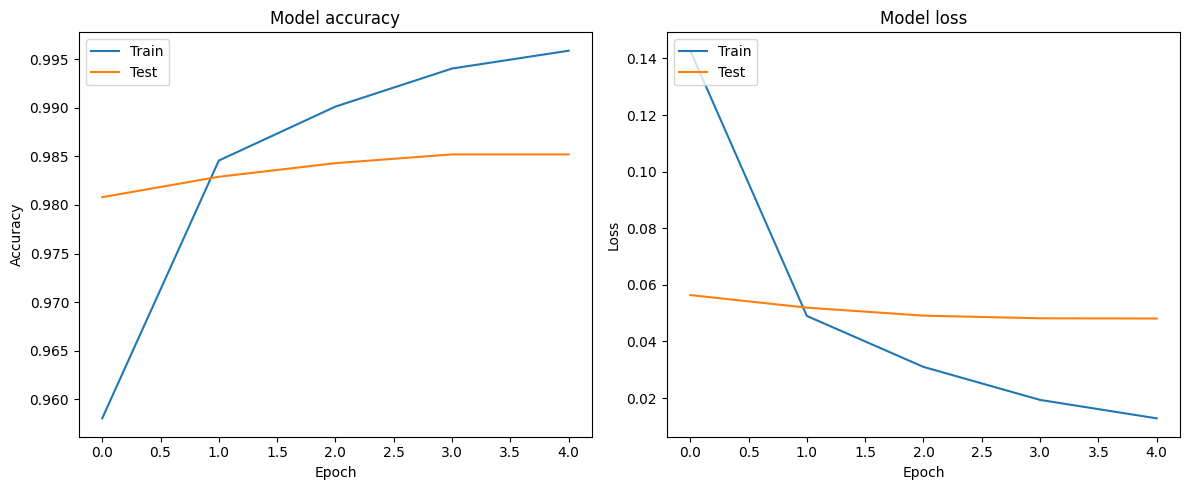

In [ ]:
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 67.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 102.5 MB/s eta 0:00:00


In [ ]:
import streamlit as st
import tensorflow as tf
import numpy as np

from PIL import Image

model = tf.keras.models.load_model(
    "digit_model.keras"
)

st.title(
    "Handwritten Digit Recognition"
)

uploaded_file = st.file_uploader(
    "Upload Digit Image",
    type=["png","jpg","jpeg"]
)

if uploaded_file:

    image = Image.open(
        uploaded_file
    ).convert("L")

    image = image.resize(
        (28,28)
    )

    img = np.array(image)

    img = img / 255.0

    img = img.reshape(
        1,
        28,
        28,
        1
    )

    prediction = model.predict(
        img
    )

    digit = np.argmax(
        prediction
    )

    st.image(
        image,
        width=200
    )

    st.success(
        f"Predicted Digit: {digit}"
    )

2026-06-14 18:09:39.257 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-14 18:09:40.041 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-06-14 18:09:40.042 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-14 18:09:40.043 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-14 18:09:40.046 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-14 18:09:40.047 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-14 18:09:40.048 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-14 18:09:40.051 Thread 'MainThread': mi

In [ ]:
import pkg_resources

# Get a list of installed packages and their versions
installed_packages = {pkg.key: pkg.version for pkg in pkg_resources.working_set}

# Filter for packages used in the notebook (TensorFlow, NumPy, Matplotlib, PIL, Streamlit)
packages_to_include = ['tensorflow', 'numpy', 'matplotlib', 'pillow', 'streamlit']

with open('requirements.txt', 'w') as f:
    for package in packages_to_include:
        if package in installed_packages:
            f.write(f"{package}=={installed_packages[package]}\n")

print("requirements.txt created successfully!")

requirements.txt created successfully!


/tmp/ipykernel_2623/2391423584.py:1: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


In [ ]:
from google.colab import files

files.download('requirements.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
streamlit_code = """import streamlit as st
import tensorflow as tf
import numpy as np

from PIL import Image

model = tf.keras.models.load_model(
    "digit_model.keras"
)

st.title(
    "Handwritten Digit Recognition"
)

uploaded_file = st.file_uploader(
    "Upload Digit Image",
    type=["png","jpg","jpeg"]
)

if uploaded_file:

    image = Image.open(
        uploaded_file
    ).convert("L")

    image = image.resize(
        (28,28)
    )

    img = np.array(image)

    img = img / 255.0

    img = img.reshape(
        1,
        28,
        28,
        1
    )

    prediction = model.predict(
        img
    )

    digit = np.argmax(
        prediction
    )

    st.image(
        image,
        width=200
    )

    st.success(
        f"Predicted Digit: {digit}"
    )"""

with open('app.py', 'w') as f:
    f.write(streamlit_code)

print("app.py created successfully!")

app.py created successfully!


In [ ]:
from google.colab import files

files.download('app.py')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>